In [1]:
#import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
#load processed dataset
df = pd.read_csv('data/Processed Data/processed_data.csv')

In [3]:
#define features and target variable
X = df.drop('MonthlyCharges', axis=1)
y = df['MonthlyCharges']

In [4]:
#separate data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
#feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
#linear regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [7]:
#decision tree regression
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [8]:
#Random Forest regression
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [9]:
#support vector regression
svr = SVR()
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

In [10]:
#KNN regression
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

In [11]:
#Evaluation function
def evaluate_model(y_test, y_pred, model_name):
    print(f"--- {model_name} ---")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))
    print("\n")

In [12]:
#Evaluate all models
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_svr, "SVR")
evaluate_model(y_test, y_pred_knn, "KNN")

--- Linear Regression ---
MAE: 4.523045282208788
MSE: 39.21337270429669
RMSE: 6.262058184358932
R2 Score: 0.9566882352287646


--- Decision Tree ---
MAE: 2.1344570617459184
MSE: 12.473915897799856
RMSE: 3.5318431304065383
R2 Score: 0.9862223707403143


--- Random Forest ---
MAE: 1.5781448012775015
MSE: 6.834247674556861
RMSE: 2.6142394065113588
R2 Score: 0.9924514698110541


--- SVR ---
MAE: 3.882241669467116
MSE: 29.40242986608992
RMSE: 5.422400747463241
R2 Score: 0.9675245703636378


--- KNN ---
MAE: 5.664435770049681
MSE: 64.46308523775728
RMSE: 8.028890660468436
R2 Score: 0.9287995448568005




In [13]:
#Comparing results
results = {
    "Linear Regression": r2_score(y_test, y_pred_lr),
    "Decision Tree": r2_score(y_test, y_pred_dt),
    "Random Forest": r2_score(y_test, y_pred_rf),
    "SVR": r2_score(y_test, y_pred_svr),
    "KNN": r2_score(y_test, y_pred_knn)
}

results_df = pd.DataFrame(list(results.items()), columns=["Model", "R2 Score"])
print(results_df.sort_values(by="R2 Score", ascending=False))

               Model  R2 Score
2      Random Forest  0.992451
1      Decision Tree  0.986222
3                SVR  0.967525
0  Linear Regression  0.956688
4                KNN  0.928800


In [14]:
#Best model
best_model = max(results, key=results.get)
print("Best Model:", best_model)

Best Model: Random Forest


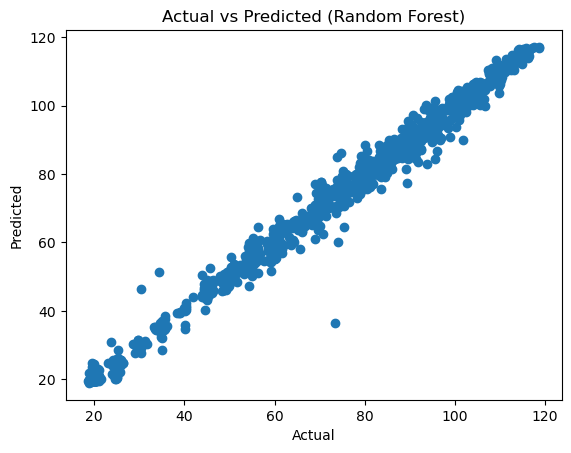

In [15]:
#Actual vs Predicted plot for best model
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

“Regression models were applied to predict MonthlyCharges. Multiple models including Linear Regression, Decision Tree, Random Forest, SVR, and KNN were evaluated using metrics such as MAE, RMSE, and R² score. The model with the highest R² score and lowest error was selected as the best performing model.”